# ClusterFinder — CUDA

Two sections, in this order:

1. **Validation** — CPU vs CUDA on `N` frames held in memory, with its own pair of
   finders. Reports µs/frame, FPS, minor faults, the cluster-count mismatch, and
   the peak clusters per frame that `CAP` has to clear. These finders are thrown
   away afterwards.
2. **Streamed pass** — the run that writes. Its own finder, trained once, carried
   across every chunk, reading `N_TOTAL` frames with only one chunk resident.

**A frame updates a finder's pedestal exactly once.** The pedestal tracks as
frames go through, so the pass cannot reuse a finder that already ran the
validation — it would count those frames twice. Hence two finders, not one; the
validation pair is disposable, so its own double-counting is harmless.

**Minor faults are the first thing to read.** A cold process pays a first-touch
fault per page of result heap it grows, inside the timer. Re-run a cell until the
count plateaus, and quote that run.

In [1]:
import sys; sys.path.append('/home/ferjao_k/aare/build')

import resource
import time
from pathlib import Path

import boost_histogram as bh
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

from aare import (File, ClusterFinder, ClusterFinderFrozen, ClusterFinderMT,
                  ClusterCollector, ClusterFinderCUDA,
                  find_cluster_views_batched_iter)
from helper import print_pinning_budget


def _faults():
    return resource.getrusage(resource.RUSAGE_SELF).ru_minflt


def report(label, t, faults, n=None, note=None):
    """One block per run, identical shape in every cell, so the three can be
    read against each other without re-reading the print statements."""
    print(f'  minor faults: {faults:>12,}')
    line = f'  {label:<20} {t * 1e6 / N:7.1f} us/frame   {N / t:>9,.0f} FPS'
    if n is not None:
        line += f'   {n:,} clusters'
    print(line)
    if note:
        print(f'  {note}')

In [2]:
def new_hist():
    """One binning for all three finders, so the spectra can be divided."""
    return bh.Histogram(bh.axis.Regular(N_BINS, E_MIN, E_MAX))


def make_hist(clusters):
    """One ClusterVector, as the serial finders return."""
    h = new_hist()
    h.fill(clusters.sum())
    return h


def make_hist_from_batch(result_list):
    h = new_hist()
    energies = [np.asarray(cv.sum()).ravel() for cv in result_list if cv.size > 0]
    if energies:
        h.fill(np.concatenate(energies))
    return h

## Configuration

In [3]:
base = Path('/mnt/sls_det_storage/highZ_data/JMulvey/Am241_SpectralResolution_2025Apr/m343_CZT_HF')
f_name  = '250407_SOURCE_Am241_Tp_15C_tint_5_master_0.json'
# pd_name = '250407_PEDESTAL_Tp_15C_tint_5_master_0.json'
pd_name = '250408_PEDESTAL2_Tp_15C_tint_5_master_0.json'
f = File(base / f_name)
pd = File(base / pd_name)

RUN_CPU = True          # CPU baseline. Off for production passes: it roughly
                         # doubles wall-clock for a comparison already made.
SERIAL  = True           # CPU baseline flavour: serial ClusterFinderFrozen, or
                         # ClusterFinderMT on N_THREADS. See N_THREADS below --
                         # the two are NOT interchangeable for a count check.

n_frames_pd  = min(11000, pd.total_frames)
N            = min(100000, f.total_frames)
cluster_size = (5, 5)
rows, cols   = f.rows, f.cols
image_size   = (rows, cols)
capacity     = 10000
BATCH_SIZE   = 2000

N_STREAMS = 4
N_SIGMA   = 5
# 4, not the throughput optimum. ClusterFinderMT gives every thread its OWN
# ClusterFinder with its own pedestal: training frames are broadcast to all of
# them, but data frames go round-robin, so each thread's pedestal then tracks on
# only 1/N_THREADS of them while CUDA's single pedestal sees every frame. The
# lagging pedestals keep a lower sigma and accept more pixels. Measured on this
# dataset, 20k frames, CPU minus CUDA: 1 thr -187, 2 -133, 4 -8, 8 +231,
# 24 +2,889. Raise it to time the CPU at its best; leave it at 4 to compare
# counts against CUDA.
N_THREADS = 4

# Fixed per-frame output slot: D2H copies it WHOLE every frame, so the cost is
# the cap, not the occupancy. Too low TRUNCATES silently. Measured over 200k
# frames of this dataset at 5x5: mean 5.2, max 18, none above 64.
CAP = 64

N_BINS = 200
E_MIN, E_MAX = -2, 4000   # spectrum range in ADU

TIME_KERNELS = False

# DEVICE_PED_TYPE is compile-time, so it cannot be read off a finder; common
# parses the header, and assert_build_fresh() refuses to run against a stale .so.
sys.path.insert(0, '/home/ferjao_k/aare/python/tests/perf')
import common
common.assert_build_fresh()
ARM = common.device_ped_type()
PRECISION = {'float': 'f32', 'double': 'f64'}[ARM]

# Cluster size + precision, in the folder AND the file names, so the f32 and f64
# builds cannot overwrite each other.
TAG = f'{cluster_size[0]}x{cluster_size[1]}_{PRECISION}'

# Streamed pass: N_CHUNK frames resident at a time, N_TOTAL frames in all.
N_CHUNK = 100_000
N_TOTAL = min(1_600_000, f.total_frames)

print(f'Build:      {ARM} -> {PRECISION}    image {image_size}  cluster {cluster_size}')
print(f'Pedestal:   {n_frames_pd:,} frames      cap {CAP}   CPU {"on" if RUN_CPU else "off"}')
print(f'Benchmark:  {N:,} frames')
print(f'Pass:       {N_TOTAL:,} frames in {-(-N_TOTAL // N_CHUNK)} x {N_CHUNK:,}  '
      f'({N_CHUNK * f.bytes_per_frame / 1e9:.1f} GB resident, '
      f'{100 * N_TOTAL / f.total_frames:.2f} % of file)')

Build:      double -> f64    image (256, 256)  cluster (5, 5)
Pedestal:   11,000 frames      cap 64   CPU on
Benchmark:  100,000 frames
Pass:       1,600,000 frames in 16 x 100,000  (13.1 GB resident, 1.00 % of file)


In [4]:
# print_pinning_budget(rows, cols)

## Validation — build the sample finders

`SERIAL` picks the CPU baseline: the sequential `ClusterFinderFrozen`, or
`ClusterFinderMT` across `N_THREADS`. `val_cpu` and `val_cuda` exist only to
compare the two implementations — nothing they see reaches the streamed pass.

In [5]:
val_cuda = ClusterFinderCUDA(image_size, cluster_size, n_sigma=N_SIGMA,
                             max_clusters_per_frame=CAP,
                             n_streams=N_STREAMS, time_kernels=TIME_KERNELS)

val_cpu = sink = None
if RUN_CPU:
    if SERIAL:
        # cf_cpu = ClusterFinder(image_size, cluster_size, n_sigma=N_SIGMA, capacity=capacity)
        val_cpu = ClusterFinderFrozen(image_size, cluster_size, n_sigma=N_SIGMA,
                                      capacity=capacity)
    else:
        val_cpu = ClusterFinderMT(image_size, cluster_size, n_sigma=N_SIGMA,
                                  capacity=capacity, n_threads=N_THREADS)
        sink = ClusterCollector(val_cpu)

## Pedestal for the validation finders

Identical frames into both, so the only thing differing between them is the
implementation.

In [6]:
pd.seek(0)
t0 = time.perf_counter()
for _ in range(n_frames_pd):
    img = pd.read_frame()
    val_cuda.push_pedestal_frame(img.copy())
    if RUN_CPU:
        val_cpu.push_pedestal_frame(img.copy())
print(f'Pedestal ({n_frames_pd:,} frames): {time.perf_counter() - t0:.2f}s')

Pedestal (11,000 frames): 4.02s


## Read the validation frames

I/O is kept out of the timing loops: both finders run over the same in-memory
`data`.

In [7]:
f.seek(0)
t0 = time.perf_counter()
data = f.read_n(N)
t_io = time.perf_counter() - t0
gb = f.bytes_per_frame * N / 1e9
print(f'Reading {N} frames: {t_io:.3f}s  ({N / t_io:,.0f} FPS, '
      f'{gb:.1f} GB at {gb / t_io:.2f} GB/s)')

Reading 100000 frames: 2.726s  (36,690 FPS, 13.1 GB at 4.81 GB/s)


## 1 — CPU, multithreaded

In [8]:
if RUN_CPU:
    mf0 = _faults()
    t0 = time.perf_counter()
    # The frame number is NOT optional bookkeeping: find_clusters(frame) defaults
    # it to 0, so every cluster comes back stamped frame 0. Counts, spectra and
    # timing are unaffected -- the number is metadata the algorithm never reads --
    # but anything per-frame is then impossible.
    for i, frame in enumerate(tqdm(data)):
        val_cpu.find_clusters(frame, i)
    t_cpu = time.perf_counter() - t0
    f_cpu = _faults() - mf0      # the drain below allocates too; bracket the loop only

    if SERIAL:
        clusters_cpu = val_cpu.steal_clusters(realloc_same_capacity=False)
        n_clusters_cpu = clusters_cpu.size
        hist_cpu = make_hist(clusters_cpu)
    else:
        val_cpu.stop(); sink.stop()
        hist_cpu = new_hist()
        n_clusters_cpu = 0
        for cv in sink.steal_clusters():
            hist_cpu.fill(cv.sum())
            n_clusters_cpu += cv.size

    label = 'CPU serial' if SERIAL else f'CPU MT ({N_THREADS} threads)'
    report(label, t_cpu, f_cpu, n_clusters_cpu)
else:
    t_cpu = f_cpu = hist_cpu = n_clusters_cpu = None
    print('  CPU run disabled (RUN_CPU)')

100%|██████████████████████████████████████| 100000/100000 [03:01<00:00, 550.15it/s]

  minor faults:        4,931
  CPU serial            1817.7 us/frame         550 FPS   518,738 clusters


## 2 — CUDA, batched + multi-streamed, pinned dataset

Pins the whole input once, then submits `BATCH_SIZE`-frame chunks across
`N_STREAMS` streams so H2D / kernel / D2H overlap. `find_clusters_batched`
allocates one `ClusterVector` per frame and copies into it — that copy is what
the next cell removes.

The pinning cost is reported separately: it is paid once, outside the loop, and
folding it into the per-frame number would charge a one-off to every frame.

In [9]:
t0 = time.perf_counter()
val_cuda.register_input_buffer(data)
t_pin = time.perf_counter() - t0

clusters_cuda = []
mf0 = _faults()
t0 = time.perf_counter()
for start in range(0, N, BATCH_SIZE):
    stop = min(start + BATCH_SIZE, N)
    clusters_cuda.extend(
        val_cuda.find_clusters_batched(data[start:stop], first_frame=start))
t_cuda = time.perf_counter() - t0
f_cuda = _faults() - mf0     # before make_hist_from_batch, which allocates GBs itself

val_cuda.unregister_input_buffer()
n_clusters_cuda = sum(cv.size for cv in clusters_cuda)
hist_cuda = make_hist_from_batch(clusters_cuda)

report('CUDA batched', t_cuda, f_cuda, n_clusters_cuda,
       note=f'pinned in {t_pin:.2f} s, once, outside the loop')
if RUN_CPU:
    print(f'  vs CPU: {t_cpu / t_cuda:.2f}x')

# One ClusterVector per frame, so this IS the per-frame maximum -- the number CAP
# has to clear. Truncation is silent.
peak_val = max((cv.size for cv in clusters_cuda), default=0)
print(f'  peak clusters in one frame: {peak_val:,} of CAP {CAP:,}')
if peak_val >= CAP:
    print('  !! CAP REACHED -- clusters were dropped; raise CAP and re-run.')

  minor faults:      119,379
  CUDA batched            14.0 us/frame      71,640 FPS   518,898 clusters
  pinned in 0.36 s, once, outside the loop
  vs CPU: 130.22x
  peak clusters in one frame: 17 of CAP 64


## Validation summary

In [10]:
runs = [('CUDA batched', t_cuda, f_cuda, n_clusters_cuda)]
if RUN_CPU:
    runs.insert(0, ('CPU serial' if SERIAL else f'CPU MT ({N_THREADS} thr)',
                    t_cpu, f_cpu, n_clusters_cpu))

head = f'{"":<20} {"us/frame":>9} {"FPS":>10} {"minor faults":>14} {"clusters":>14}'
print(head + ('  vs CPU   diff vs CPU' if RUN_CPU else ''))
for name, t, flt, n in runs:
    line = f'{name:<20} {t * 1e6 / N:9.1f} {N / t:10,.0f} {flt:>14,} {n:>14,}'
    if RUN_CPU:
        d = abs(n - n_clusters_cpu)
        line += f'  {t_cpu / t:5.2f}x  {d:>6,} ({d / max(n_clusters_cpu, 1):.4%})'
    print(line)

                      us/frame        FPS   minor faults       clusters  vs CPU   diff vs CPU
CPU serial              1817.7        550          4,931        518,738   1.00x       0 (0.0000%)
CUDA batched              14.0     71,640        119,379        518,898  130.22x     160 (0.0308%)


## Validation spectrum

With `RUN_CPU`, the curves should lie on top of each other. A departure is a
pedestal-update difference, not the result path — and at high `N_THREADS` it is
mostly `ClusterFinderMT`'s per-thread pedestals rather than anything CUDA does.

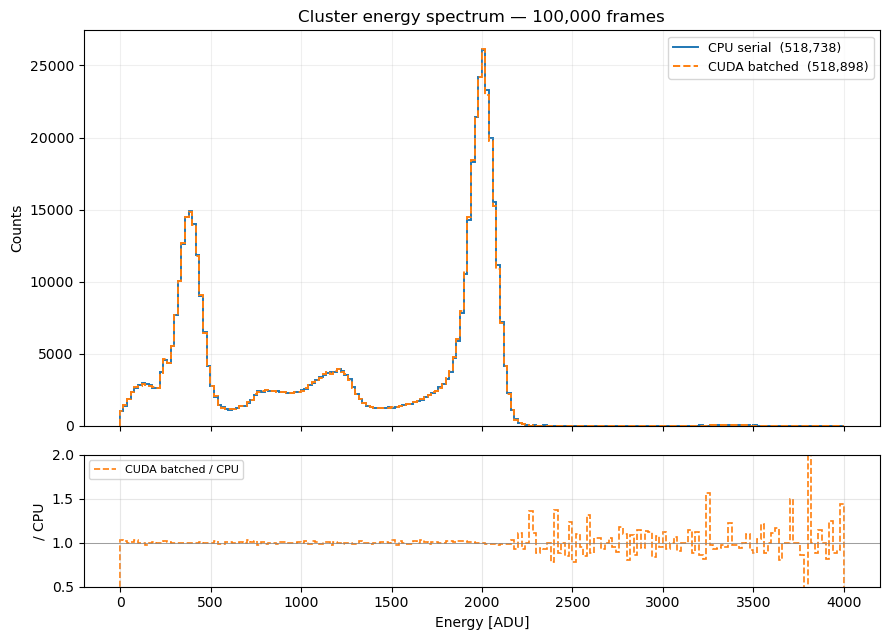

In [11]:
series = [('CUDA batched', hist_cuda, n_clusters_cuda, '--', 'C1')]
if RUN_CPU:
    series.insert(0, ('CPU serial' if SERIAL else f'CPU MT ({N_THREADS} thr)',
                      hist_cpu, n_clusters_cpu, '-', 'C0'))

if RUN_CPU:
    fig, (ax_spec, ax_ratio) = plt.subplots(
        2, 1, figsize=(9, 6.5), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
else:
    fig, ax_spec = plt.subplots(figsize=(9, 4.5))
    ax_ratio = None

edges = hist_cuda.axes[0].edges
for label, h, n, ls, col in series:
    ax_spec.stairs(h.values(), edges, label=f'{label}  ({n:,})',
                   linestyle=ls, color=col, linewidth=1.4)
ax_spec.set_ylabel('Counts')
ax_spec.set_title(f'Cluster energy spectrum — {N:,} frames')
ax_spec.legend(fontsize=9)
ax_spec.grid(alpha=0.2)

if ax_ratio is not None:
    cpu_vals = hist_cpu.values()
    with np.errstate(divide='ignore', invalid='ignore'):
        for label, h, n, ls, col in series[1:]:
            r = np.where(cpu_vals > 0, h.values() / cpu_vals, np.nan)
            ax_ratio.stairs(r, edges, label=f'{label} / CPU',
                            linestyle=ls, color=col, linewidth=1.2)
    ax_ratio.axhline(1.0, color='gray', linewidth=0.5)
    ax_ratio.set_ylabel('/ CPU')
    ax_ratio.set_ylim(0.5, 2.0)
    ax_ratio.legend(fontsize=8)
    ax_ratio.grid(alpha=0.3)
    ax_ratio.set_xlabel('Energy [ADU]')
else:
    ax_spec.set_xlabel('Energy [ADU]')

plt.tight_layout()
plt.show()

## Streamed pass — the run that writes

Read `N_CHUNK` frames → find → write that chunk out → drop it. Resident memory is
flat at one chunk however far `N_TOTAL` goes; the validation above holds
everything at once and cannot scale (160 M frames is 21 TB, and one
`ClusterVector` per frame would cost ~16 GB of object overhead before storing a
cluster).

The finder is **built and trained here**, not carried over from the validation:
that one has already pulled the validation frames into its pedestal. This one is
then reused for every chunk, so the pedestal tracks continuously across the whole
pass and each frame contributes to it exactly once.

Each chunk is its own `.npy` triple, `part0000`, `part0001`, … — the final
cluster count is unknowable in advance and a `.npy` needs its shape up front, and
parts mean a run that dies at chunk 9 leaves 0–8 readable.

| file | what it holds |
|---|---|
| `clusters_<TAG>_partNNNN.npy` | that chunk's clusters, frames in order |
| `frame_index_<TAG>_partNNNN.npy` | offsets — frame *k* is `clusters[idx[k]:idx[k+1]]` |
| `frame_numbers_<TAG>_partNNNN.npy` | the frame number each slot came from |
| `manifest.json` | tag, precision, cap, per-part counts, wall time, dtype |

In [12]:
import gc
import json
import shutil
from numpy.lib.format import open_memmap

# The dataset folder is nobody:nobody 755; its parent is 777.
SAVE_DIR = base.parent / 'cluster_dumps' / base.name / f'cuda_{TAG}'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Release the validation state -- its finders and its N frames -- before the pass
# starts allocating chunks of its own.
for _n in ('data', 'clusters_cuda', 'val_cpu', 'val_cuda', 'sink'):
    globals().pop(_n, None)
gc.collect()

# Its own finder, trained here. val_cuda has already seen the validation frames
# and folded them into its pedestal; reusing it would count them a second time.
# This one is then used for every chunk, so the pedestal tracks continuously and
# each frame updates it exactly once.
cf_cuda = ClusterFinderCUDA(image_size, cluster_size, n_sigma=N_SIGMA,
                            max_clusters_per_frame=CAP,
                            n_streams=N_STREAMS, time_kernels=TIME_KERNELS)
pd.seek(0)
for _ in range(n_frames_pd):
    cf_cuda.push_pedestal_frame(pd.read_frame().copy())


def write_part(vectors, part):
    """One chunk -> one .npy triple. np.asarray(cv) is a view that dies with the
    vector; open_memmap writes through, so no second copy of the chunk."""
    n = sum(cv.size for cv in vectors)
    stem = f'{TAG}_part{part:04d}'
    arr = open_memmap(SAVE_DIR / f'clusters_{stem}.npy', mode='w+',
                      dtype=np.asarray(vectors[0]).dtype, shape=(n,))
    index = np.zeros(len(vectors) + 1, dtype=np.int64)
    frames = np.zeros(len(vectors), dtype=np.uint32)
    i = 0
    for k, cv in enumerate(vectors):
        m = cv.size
        if m:
            arr[i:i + m] = np.asarray(cv)
        frames[k] = cv.frame_number
        i += m
        index[k + 1] = i
    arr.flush()
    del arr
    np.save(SAVE_DIR / f'frame_index_{stem}.npy', index)
    np.save(SAVE_DIR / f'frame_numbers_{stem}.npy', frames)
    return n, int(np.diff(index).max(initial=0))


n_parts = -(-N_TOTAL // N_CHUNK)
print(f'{N_TOTAL:,} frames -> {n_parts} parts, {SAVE_DIR}')

hist_pass = new_hist()
done = clusters_total = peak_total = 0
t_io = t_gpu = t_save = 0.0
part_counts = []
f.seek(0)
t_wall = time.perf_counter()

bar = tqdm(total=N_TOTAL, unit='frame', unit_scale=True, desc='pass')
for part in range(n_parts):
    t0 = time.perf_counter()
    chunk = f.read_n(min(N_CHUNK, N_TOTAL - done))
    nf = len(chunk)                  # kept: chunk is deleted before it is used
    t_io += time.perf_counter() - t0

    t0 = time.perf_counter()
    cf_cuda.register_input_buffer(chunk)
    vecs = []
    for s in tqdm(range(0, nf, BATCH_SIZE), desc=f'part {part} gpu',
                  unit='batch', leave=False):
        e = min(s + BATCH_SIZE, nf)
        vecs.extend(cf_cuda.find_clusters_batched(chunk[s:e], first_frame=done + s))
    cf_cuda.unregister_input_buffer()
    t_gpu += time.perf_counter() - t0

    t0 = time.perf_counter()
    hist_pass += make_hist_from_batch(vecs)
    n, peak = write_part(vecs, part)
    t_save += time.perf_counter() - t0

    done += nf
    clusters_total += n
    peak_total = max(peak_total, peak)
    part_counts.append({'part': part, 'first_frame': done - nf,
                        'n_frames': nf, 'n_clusters': n, 'peak': peak})
    del vecs, chunk

    bar.update(nf)
    bar.set_postfix(clusters=f'{clusters_total:,}', peak=peak_total)

    if peak >= CAP:
        bar.close()
        raise RuntimeError(f'CAP {CAP} reached in part {part}: clusters dropped, '
                           f'parts so far are truncated. Raise CAP and re-run.')
bar.close()

wall = time.perf_counter() - t_wall
(SAVE_DIR / 'manifest.json').write_text(json.dumps(
    {'tag': TAG, 'precision': PRECISION, 'arm': ARM,
     'cluster_size': list(cluster_size), 'image_size': list(image_size),
     'n_sigma': N_SIGMA, 'cap': CAP, 'pedestal_frames': n_frames_pd,
     'pedestal_file': pd_name, 'data_file': f_name,
     'n_frames': done, 'n_clusters': clusters_total,
     'peak_clusters_per_frame': peak_total, 'n_parts': n_parts,
     'wall_seconds': round(wall, 1),
     'dtype': str(np.dtype([('x', '<u2'), ('y', '<u2'),
                            ('data', '<i4', tuple(cluster_size))])),
     'parts': part_counts}, indent=2))

written = sum(p.stat().st_size for p in SAVE_DIR.glob('*.npy'))
print(f'\n{done:,} frames in {wall / 60:.1f} min   ({done / wall:,.0f} FPS end to end)')
print(f'   io {t_io / 60:.1f} + gpu {t_gpu / 60:.1f} + save {t_save / 60:.1f} min')
print(f'   {clusters_total:,} clusters ({clusters_total / done:.2f}/frame)  '
      f'peak {peak_total}/{CAP}   {written / 1e9:.2f} GB in {n_parts * 3} files')
print(f'   projected: {f.total_frames / 1e6:.0f}M frames -> '
      f'{wall * f.total_frames / done / 3600:.1f} h, '
      f'{written * f.total_frames / done / 1e12:.2f} TB')

1,600,000 frames -> 16 parts, /mnt/sls_det_storage/highZ_data/JMulvey/Am241_SpectralResolution_2025Apr/cluster_dumps/m343_CZT_HF/cuda_5x5_f64


pass:   0%|                                         | 0.00/1.60M [00:00<?, ?frame/s]
part 0 gpu:  96%|██████████████████████████████▋ | 48/50 [00:01<00:00, 36.74batch/s]
pass:   6%|▍     | 100k/1.60M [00:06<01:37, 15.4kframe/s, clusters=518,898, peak=17]
part 1 gpu:  96%|██████████████████████████████▋ | 48/50 [00:01<00:00, 37.22batch/s]
pass:  12%|▌   | 200k/1.60M [00:57<01:20, 17.4kframe/s, clusters=1,040,398, peak=18]
part 2 gpu:  96%|██████████████████████████████▋ | 48/50 [00:01<00:00, 36.91batch/s]
pass:  19%|▊   | 300k/1.60M [01:39<05:35, 3.87kframe/s, clusters=1,560,561, peak=18]
part 3 gpu:  94%|██████████████████████████████  | 47/50 [00:01<00:00, 36.30batch/s]
pass:  25%|█   | 400k/1.60M [02:15<06:26, 3.11kframe/s, clusters=2,080,583, peak=19]
part 4 gpu:  94%|██████████████████████████████  | 47/50 [00:01<00:00, 36.87batch/s]
pass:  31%|█▎  | 500k/1.60M [02:53<06:08, 2.98kframe/s, clusters=2,601,711, peak=19]
part 5 gpu:  94%|██████████████████████████████  | 47/50 [00:01<0


1,600,000 frames in 10.1 min   (2,635 FPS end to end)
   io 9.1 + gpu 0.6 + save 0.4 min
   8,331,411 clusters (5.21/frame)  peak 21/64   0.89 GB in 48 files
   projected: 160M frames -> 16.9 h, 0.09 TB


## Read the pass back

Plain `.npy` plus the manifest — numpy only, no `aare`.

16 parts, 1,600,000 frames, 8,331,411 clusters, 5x5_f64, 10.1 min
part 0 frame 50000: 5 clusters, energies [1993 2063 1284  249] ADU


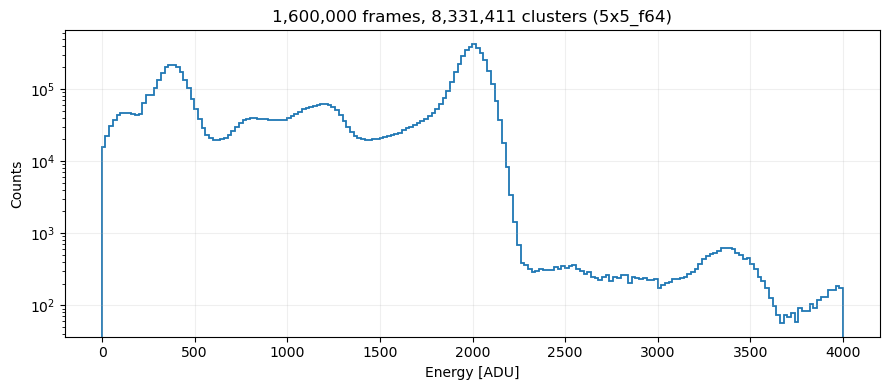

In [13]:
man = json.loads((SAVE_DIR / 'manifest.json').read_text())


def load_part(part):
    stem = f"{man['tag']}_part{part:04d}"
    return (np.load(SAVE_DIR / f'clusters_{stem}.npy', mmap_mode='r'),
            np.load(SAVE_DIR / f'frame_index_{stem}.npy'),
            np.load(SAVE_DIR / f'frame_numbers_{stem}.npy'))


total = sum(load_part(p)[0].shape[0] for p in range(man['n_parts']))
assert total == man['n_clusters']

cl, ix, fn = load_part(0)
k = len(fn) // 2
one = cl[ix[k]:ix[k + 1]]
print(f"{man['n_parts']} parts, {man['n_frames']:,} frames, {total:,} clusters, "
      f"{man['tag']}, {man['wall_seconds'] / 60:.1f} min")
print(f'part 0 frame {fn[k]}: {one.size} clusters, '
      f'energies {one["data"].sum(axis=(1, 2))[:4]} ADU')

fig, ax = plt.subplots(figsize=(9, 4))
ax.stairs(hist_pass.values(), hist_pass.axes[0].edges, linewidth=1.3)
ax.set_yscale('log')
ax.set_xlabel('Energy [ADU]')
ax.set_ylabel('Counts')
ax.set_title(f"{man['n_frames']:,} frames, {man['n_clusters']:,} clusters ({man['tag']})")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()